In [54]:
# Cell 1: Import Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


In [55]:
# Cell 2: Load Dataset

DATA_PATH = "onionn_market_1000.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (1000, 9)


,date,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg
0,2023-01-01,Delhi,Onion,28.3,16.5,0.0,18889,0,1444
1,2023-01-02,Delhi,Onion,28.4,16.3,0.0,19809,0,1518
2,2023-01-03,Delhi,Onion,27.8,16.0,0.0,18630,0,1426
3,2023-01-04,Delhi,Onion,28.1,16.5,0.1,18429,0,1399
4,2023-01-05,Delhi,Onion,28.6,16.4,0.0,18570,0,1411


In [56]:
# Cell 3: Dataset Information

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 1000
Number of columns: 9

Column names:
['date', 'location', 'crop', 'price_per_kg', 'temperature_c', 'rainfall_mm', 'market_arrivals_kg', 'festival_flag', 'demand_kg']

Data types:
date                      str
location                  str
crop                      str
price_per_kg          float64
temperature_c         float64
rainfall_mm           float64
market_arrivals_kg      int64
festival_flag           int64
demand_kg               int64
dtype: object


In [57]:
# Cell 4: Missing Value Check

missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

display(missing_values)

,Missing Count,Missing Percentage
date,0,0.0
location,0,0.0
crop,0,0.0
price_per_kg,0,0.0
temperature_c,0,0.0
rainfall_mm,0,0.0
market_arrivals_kg,0,0.0
festival_flag,0,0.0
demand_kg,0,0.0


In [58]:
# Cell 5: Duplicate Check

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [59]:
# Cell 6: Unique Locations and Crops

print("Locations:")
print(sorted(df["location"].unique()))

print("\nNumber of locations:")
print(df["location"].nunique())

print("\nCrops:")
print(sorted(df["crop"].unique()))

print("\nNumber of crops:")
print(df["crop"].nunique())

Locations:
['Delhi', 'Faridabad', 'Ghaziabad', 'Gurugram', 'Meerut', 'Noida', 'Panipat', 'Sonipat']

Number of locations:
8

Crops:
['Onion']

Number of crops:
1


In [60]:
# Cell 7: Date Range

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())

Minimum date: 2023-01-01 00:00:00
Maximum date: 2025-09-26 00:00:00


In [61]:
# Cell 8: Descriptive Statistics

display(df.describe())

,date,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2024-05-14 12:00:00,29.663000,25.346800,0.147500,10140.071000,0.091000,785.970000
min,2023-01-01 00:00:00,26.600000,15.200000,0.000000,5959.000000,0.000000,444.000000
25%,2023-09-07 18:00:00,28.500000,18.800000,0.000000,7955.000000,0.000000,612.750000
50%,2024-05-14 12:00:00,29.700000,25.700000,0.000000,9028.000000,0.000000,696.500000
75%,2025-01-19 06:00:00,30.700000,31.800000,0.000000,10152.750000,0.000000,792.000000
max,2025-09-26 00:00:00,35.200000,35.000000,9.700000,21665.000000,1.000000,1863.000000
std,NaN,1.469561,6.475548,0.554365,3843.211744,0.287753,300.488533


In [62]:
# Cell 9: Standardize Column Names

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

print("Standardized columns:")
print(df.columns.tolist())

Standardized columns:
['date', 'location', 'crop', 'price_per_kg', 'temperature_c', 'rainfall_mm', 'market_arrivals_kg', 'festival_flag', 'demand_kg']


In [63]:
# Cell 10: Convert Data Types

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

df["location"] = (
    df["location"]
    .astype(str)
    .str.strip()
)

df["crop"] = (
    df["crop"]
    .astype(str)
    .str.strip()
)

numeric_columns = [
    "price_per_kg",
    "temperature_c",
    "rainfall_mm",
    "market_arrivals_kg",
    "festival_flag",
    "demand_kg"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print(df.dtypes)

date                  datetime64[us]
location                         str
crop                             str
price_per_kg                 float64
temperature_c                float64
rainfall_mm                  float64
market_arrivals_kg             int64
festival_flag                  int64
demand_kg                      int64
dtype: object


In [64]:
# Cell 11: Handle Invalid Values

print("Negative price:",
      (df["price_per_kg"] < 0).sum())

print("Negative rainfall:",
      (df["rainfall_mm"] < 0).sum())

print("Negative arrivals:",
      (df["market_arrivals_kg"] < 0).sum())

print("Negative demand:",
      (df["demand_kg"] < 0).sum())

# Mark impossible values as missing
df.loc[df["price_per_kg"] < 0, "price_per_kg"] = np.nan
df.loc[df["rainfall_mm"] < 0, "rainfall_mm"] = np.nan
df.loc[df["market_arrivals_kg"] < 0, "market_arrivals_kg"] = np.nan
df.loc[df["demand_kg"] < 0, "demand_kg"] = np.nan

# Demand is the target, so don't fabricate missing target values
df = df.dropna(subset=["demand_kg"])

print("\nRemaining rows:", len(df))

Negative price: 0
Negative rainfall: 0
Negative arrivals: 0
Negative demand: 0

Remaining rows: 1000


In [65]:
# Cell 12: Sort Dataset Chronologically

df = df.sort_values(
    ["location", "crop", "date"]
).reset_index(drop=True)

display(df.head(10))

,date,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg
0,2023-01-01,Delhi,Onion,28.3,16.5,0.0,18889.0,0,1444.0
1,2023-01-02,Delhi,Onion,28.4,16.3,0.0,19809.0,0,1518.0
2,2023-01-03,Delhi,Onion,27.8,16.0,0.0,18630.0,0,1426.0
3,2023-01-04,Delhi,Onion,28.1,16.5,0.1,18429.0,0,1399.0
4,2023-01-05,Delhi,Onion,28.6,16.4,0.0,18570.0,0,1411.0
5,2023-02-10,Delhi,Onion,28.5,17.3,0.0,17957.0,0,1375.0
6,2023-02-11,Delhi,Onion,28.9,17.2,0.0,19080.0,0,1473.0
7,2023-02-12,Delhi,Onion,28.8,17.0,0.0,19826.0,0,1515.0
8,2023-02-13,Delhi,Onion,28.5,17.4,0.0,19196.0,0,1466.0
9,2023-02-14,Delhi,Onion,28.3,17.0,0.0,19615.0,0,1492.0


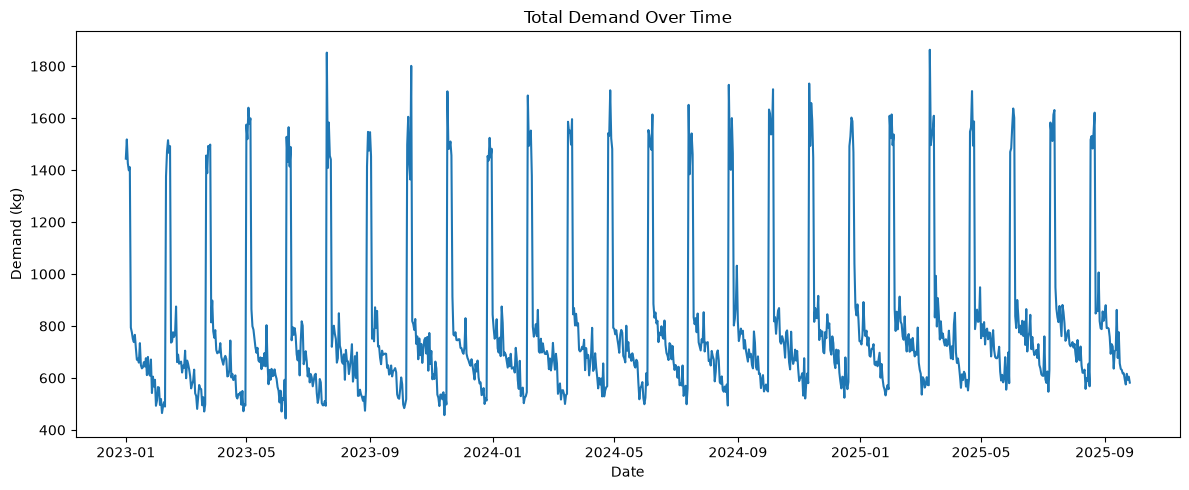

In [66]:
# Cell 13: Demand Over Time

daily_demand = (
    df.groupby("date")["demand_kg"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    daily_demand["date"],
    daily_demand["demand_kg"]
)

plt.title("Total Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand (kg)")

plt.tight_layout()
plt.show()

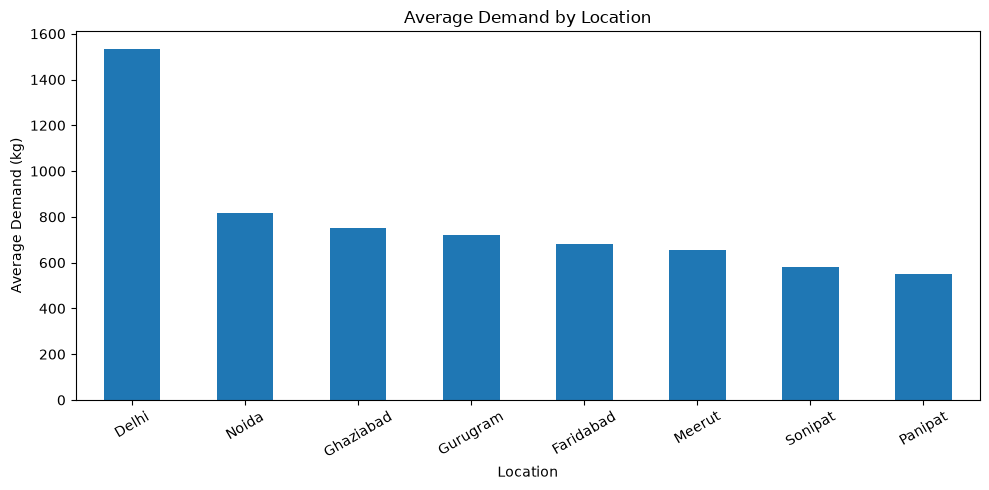

In [67]:
# Cell 14: Average Demand by Location

location_demand = (
    df.groupby("location")["demand_kg"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

location_demand.plot(
    kind="bar"
)

plt.title("Average Demand by Location")
plt.xlabel("Location")
plt.ylabel("Average Demand (kg)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

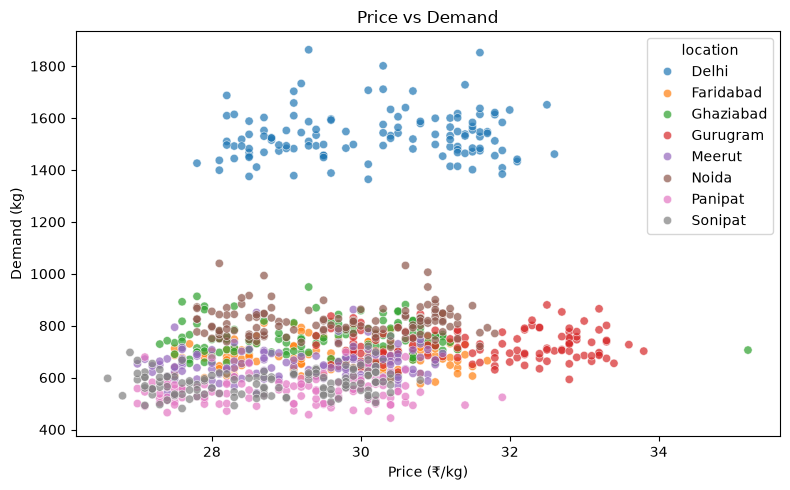

In [68]:
# Cell 15: Price vs Demand

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="price_per_kg",
    y="demand_kg",
    hue="location",
    alpha=0.7
)

plt.title("Price vs Demand")
plt.xlabel("Price (₹/kg)")
plt.ylabel("Demand (kg)")

plt.tight_layout()
plt.show()

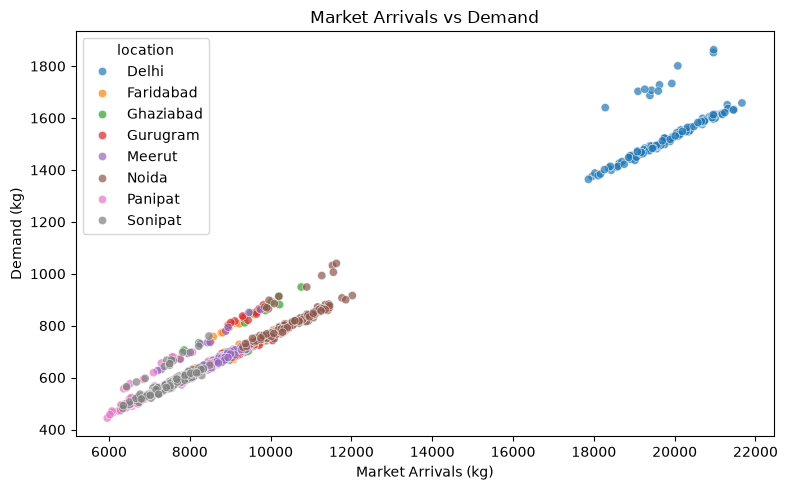

In [69]:
# Cell 16: Market Arrivals vs Demand

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="market_arrivals_kg",
    y="demand_kg",
    hue="location",
    alpha=0.7
)

plt.title("Market Arrivals vs Demand")
plt.xlabel("Market Arrivals (kg)")
plt.ylabel("Demand (kg)")

plt.tight_layout()
plt.show()

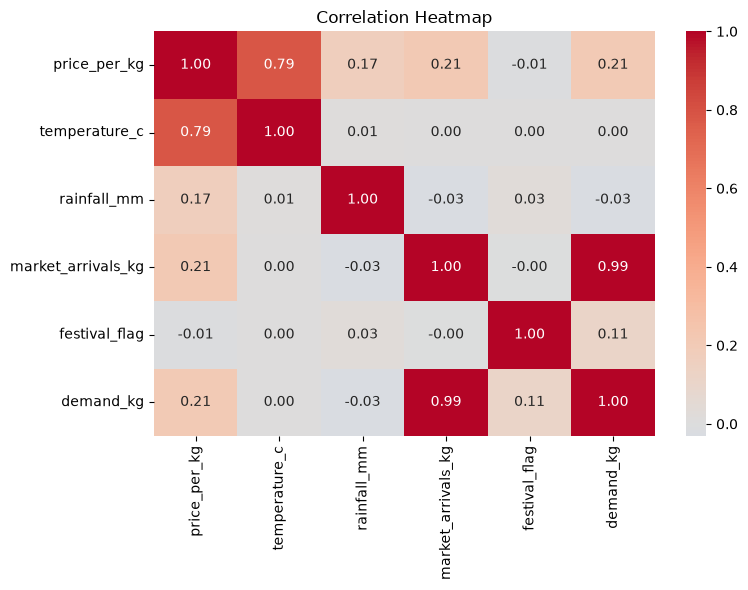

In [70]:
# Cell 17: Correlation Heatmap

numeric_columns = [
    "price_per_kg",
    "temperature_c",
    "rainfall_mm",
    "market_arrivals_kg",
    "festival_flag",
    "demand_kg"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [71]:
# Cell 18: Calendar Feature Engineering

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_year"] = df["date"].dt.dayofyear
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["date"].dt.quarter

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

# Cyclical month
df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)

# Cyclical day of week
df["day_of_week_sin"] = np.sin(
    2 * np.pi * df["day_of_week"] / 7
)

df["day_of_week_cos"] = np.cos(
    2 * np.pi * df["day_of_week"] / 7
)

display(
    df[
        [
            "date",
            "year",
            "month",
            "day",
            "day_of_week",
            "day_of_year",
            "week_of_year",
            "quarter",
            "is_weekend"
        ]
    ].head()
)

,date,year,month,day,day_of_week,day_of_year,week_of_year,quarter,is_weekend
0,2023-01-01,2023,1,1,6,1,52,1,1
1,2023-01-02,2023,1,2,0,2,1,1,0
2,2023-01-03,2023,1,3,1,3,1,1,0
3,2023-01-04,2023,1,4,2,4,1,1,0
4,2023-01-05,2023,1,5,3,5,1,1,0


In [72]:
# Cell 19: Lag Features

lag_values = [
    1,
    2,
    3,
    7,
    14,
    30
]

for lag in lag_values:

    df[f"lag_{lag}"] = (
        df.groupby(
            ["location", "crop"]
        )["demand_kg"]
        .shift(lag)
    )

print("Lag features created.")

display(
    df[
        [
            "date",
            "location",
            "crop",
            "lag_1",
            "lag_2",
            "lag_3",
            "lag_7",
            "lag_14",
            "lag_30"
        ]
    ].head(35)
)

Lag features created.


,date,location,crop,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30
0,2023-01-01,Delhi,Onion,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-02,Delhi,Onion,1444.0,NaN,NaN,NaN,NaN,NaN
2,2023-01-03,Delhi,Onion,1518.0,1444.0,NaN,NaN,NaN,NaN
3,2023-01-04,Delhi,Onion,1426.0,1518.0,1444.0,NaN,NaN,NaN
4,2023-01-05,Delhi,Onion,1399.0,1426.0,1518.0,NaN,NaN,NaN
5,2023-02-10,Delhi,Onion,1411.0,1399.0,1426.0,NaN,NaN,NaN
6,2023-02-11,Delhi,Onion,1375.0,1411.0,1399.0,NaN,NaN,NaN
7,2023-02-12,Delhi,Onion,1473.0,1375.0,1411.0,1444.0,NaN,NaN
8,2023-02-13,Delhi,Onion,1515.0,1473.0,1375.0,1518.0,NaN,NaN
9,2023-02-14,Delhi,Onion,1466.0,1515.0,1473.0,1426.0,NaN,NaN


In [73]:
# Cell 20: Rolling Features

grouped_demand = df.groupby(
    ["location", "crop"]
)["demand_kg"]

df["rolling_mean_7"] = (
    grouped_demand
    .transform(
        lambda x:
        x.shift(1)
        .rolling(7)
        .mean()
    )
)

df["rolling_mean_14"] = (
    grouped_demand
    .transform(
        lambda x:
        x.shift(1)
        .rolling(14)
        .mean()
    )
)

df["rolling_mean_30"] = (
    grouped_demand
    .transform(
        lambda x:
        x.shift(1)
        .rolling(30)
        .mean()
    )
)

df["rolling_std_7"] = (
    grouped_demand
    .transform(
        lambda x:
        x.shift(1)
        .rolling(7)
        .std()
    )
)

df["rolling_std_30"] = (
    grouped_demand
    .transform(
        lambda x:
        x.shift(1)
        .rolling(30)
        .std()
    )
)

rolling_features = [
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_std_7",
    "rolling_std_30"
]

display(
    df[
        ["date", "location", "crop"]
        + rolling_features
    ].head(35)
)

,date,location,crop,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,rolling_std_30
0,2023-01-01,Delhi,Onion,NaN,NaN,NaN,NaN,NaN
1,2023-01-02,Delhi,Onion,NaN,NaN,NaN,NaN,NaN
2,2023-01-03,Delhi,Onion,NaN,NaN,NaN,NaN,NaN
3,2023-01-04,Delhi,Onion,NaN,NaN,NaN,NaN,NaN
4,2023-01-05,Delhi,Onion,NaN,NaN,NaN,NaN,NaN
5,2023-02-10,Delhi,Onion,NaN,NaN,NaN,NaN,NaN
6,2023-02-11,Delhi,Onion,NaN,NaN,NaN,NaN,NaN
7,2023-02-12,Delhi,Onion,1435.142857,NaN,NaN,48.247378,NaN
8,2023-02-13,Delhi,Onion,1445.285714,NaN,NaN,57.075138,NaN
9,2023-02-14,Delhi,Onion,1437.857143,NaN,NaN,48.820858,NaN


In [74]:
# Cell 21: Remove Initial Lag/Rolling NaN Rows

before = len(df)

required_history_columns = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_std_7",
    "rolling_std_30"
]

df_model = df.dropna(
    subset=required_history_columns
).copy()

df_model = df_model.sort_values(
    "date"
).reset_index(drop=True)

after = len(df_model)

print("Rows before:", before)
print("Rows after :", after)
print("Rows removed:", before - after)

Rows before: 1000
Rows after : 760
Rows removed: 240


In [75]:
# Cell 22: Define Features and Target

feature_columns = [

    # Categorical
    "location",
    "crop",

    # Market / weather
    "price_per_kg",
    "temperature_c",
    "rainfall_mm",
    "market_arrivals_kg",
    "festival_flag",

    # Calendar
    "year",
    "month",
    "day",
    "day_of_week",
    "day_of_year",
    "week_of_year",
    "quarter",
    "is_weekend",

    # Cyclical
    "month_sin",
    "month_cos",
    "day_of_week_sin",
    "day_of_week_cos",

    # Lag
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",

    # Rolling
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_std_7",
    "rolling_std_30"
]

target_column = "demand_kg"

X = df_model[
    feature_columns
].copy()

y = df_model[
    target_column
].copy()

print("Feature shape:", X.shape)
print("Target shape :", y.shape)

print("\nFeatures:")
print(feature_columns)

Feature shape: (760, 30)
Target shape : (760,)

Features:
['location', 'crop', 'price_per_kg', 'temperature_c', 'rainfall_mm', 'market_arrivals_kg', 'festival_flag', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend', 'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_std_7', 'rolling_std_30']


In [76]:
# Cell 23: Chronological Split

unique_dates = np.array(
    sorted(df_model["date"].unique())
)

number_of_dates = len(unique_dates)

train_end = int(
    number_of_dates * 0.70
)

validation_end = int(
    number_of_dates * 0.85
)

train_dates = unique_dates[
    :train_end
]

validation_dates = unique_dates[
    train_end:validation_end
]

test_dates = unique_dates[
    validation_end:
]

train_df = df_model[
    df_model["date"].isin(train_dates)
].copy()

validation_df = df_model[
    df_model["date"].isin(validation_dates)
].copy()

test_df = df_model[
    df_model["date"].isin(test_dates)
].copy()

print("TRAIN")
print(
    train_df["date"].min(),
    "→",
    train_df["date"].max()
)

print("\nVALIDATION")
print(
    validation_df["date"].min(),
    "→",
    validation_df["date"].max()
)

print("\nTEST")
print(
    test_df["date"].min(),
    "→",
    test_df["date"].max()
)

TRAIN
2023-08-29 00:00:00 → 2025-02-10 00:00:00

VALIDATION
2025-02-11 00:00:00 → 2025-06-04 00:00:00

TEST
2025-06-05 00:00:00 → 2025-09-26 00:00:00


In [77]:
# Cell 24: Create Training / Validation / Test Data

X_train = train_df[
    feature_columns
].copy()

y_train = train_df[
    target_column
].copy()

X_val = validation_df[
    feature_columns
].copy()

y_val = validation_df[
    target_column
].copy()

X_test = test_df[
    feature_columns
].copy()

y_test = test_df[
    target_column
].copy()

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

X_train: (532, 30)
X_val  : (114, 30)
X_test : (114, 30)

y_train: (532,)
y_val  : (114,)
y_test : (114,)


In [78]:
# Cell 25: Preprocessing Pipeline

categorical_features = [
    "location",
    "crop"
]

numeric_features = [
    column
    for column in feature_columns
    if column not in categorical_features
]

try:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        encoder
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [79]:
# Cell 26: Create Linear Regression Pipeline

linear_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LinearRegression()
    )
])

print("Linear Regression pipeline created.")

Linear Regression pipeline created.


In [80]:
# Cell 27: Train Linear Regression

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [81]:
# Cell 28: Generate Predictions

train_predictions = (
    linear_model
    .predict(X_train)
)

validation_predictions = (
    linear_model
    .predict(X_val)
)

test_predictions = (
    linear_model
    .predict(X_test)
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [82]:
# Cell 29: Evaluation Metrics

def safe_mape(
    actual,
    predicted
):

    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    mask = actual != 0

    if mask.sum() == 0:
        return np.nan

    return (
        np.mean(
            np.abs(
                (actual[mask] - predicted[mask])
                / actual[mask]
            )
        )
        * 100
    )


def calculate_metrics(
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    mape = safe_mape(
        actual,
        predicted
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE (%)": mape
    }


train_metrics = calculate_metrics(
    y_train,
    train_predictions
)

validation_metrics = calculate_metrics(
    y_val,
    validation_predictions
)

test_metrics = calculate_metrics(
    y_test,
    test_predictions
)

print("TRAIN")
print(train_metrics)

print("\nVALIDATION")
print(validation_metrics)

print("\nTEST")
print(test_metrics)

TRAIN
{'MAE': 9.64921112157968, 'RMSE': np.float64(15.346573534427172), 'R2': 0.9974754416438258, 'MAPE (%)': np.float64(1.216533712216124)}

VALIDATION
{'MAE': 11.754238670725977, 'RMSE': np.float64(19.273388027609908), 'R2': 0.9961248712866775, 'MAPE (%)': np.float64(1.4764263294856501)}

TEST
{'MAE': 8.870261673902318, 'RMSE': np.float64(10.655681290942653), 'R2': 0.9982238158696023, 'MAPE (%)': np.float64(1.1972086617853899)}


In [83]:
# Cell 30: Performance Summary

performance = pd.DataFrame({

    "Dataset": [
        "Train",
        "Validation",
        "Test"
    ],

    "MAE": [
        train_metrics["MAE"],
        validation_metrics["MAE"],
        test_metrics["MAE"]
    ],

    "RMSE": [
        train_metrics["RMSE"],
        validation_metrics["RMSE"],
        test_metrics["RMSE"]
    ],

    "R2": [
        train_metrics["R2"],
        validation_metrics["R2"],
        test_metrics["R2"]
    ],

    "MAPE (%)": [
        train_metrics["MAPE (%)"],
        validation_metrics["MAPE (%)"],
        test_metrics["MAPE (%)"]
    ]

})

display(
    performance.round(3)
)

,Dataset,MAE,RMSE,R2,MAPE (%)
0,Train,9.649,15.347,0.997,1.217
1,Validation,11.754,19.273,0.996,1.476
2,Test,8.870,10.656,0.998,1.197


In [84]:
# Cell 31: Time Series Cross Validation

tscv = TimeSeriesSplit(
    n_splits=4
)

cv_mae = []
cv_rmse = []
cv_r2 = []

for fold, (
    train_index,
    validation_index
) in enumerate(
    tscv.split(X_train),
    start=1
):

    X_fold_train = X_train.iloc[
        train_index
    ]

    y_fold_train = y_train.iloc[
        train_index
    ]

    X_fold_validation = X_train.iloc[
        validation_index
    ]

    y_fold_validation = y_train.iloc[
        validation_index
    ]

    # Create a fresh model for this fold
    fold_model = Pipeline([
        (
            "preprocessor",
            ColumnTransformer([
                (
                    "numeric",
                    SimpleImputer(
                        strategy="median"
                    ),
                    numeric_features
                ),
                (
                    "categorical",
                    Pipeline([
                        (
                            "imputer",
                            SimpleImputer(
                                strategy="most_frequent"
                            )
                        ),
                        (
                            "encoder",
                            OneHotEncoder(
                                handle_unknown="ignore",
                                sparse_output=False
                            )
                        )
                    ]),
                    categorical_features
                )
            ])
        ),
        (
            "model",
            LinearRegression()
        )
    ])

    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    fold_predictions = fold_model.predict(
        X_fold_validation
    )

    fold_mae_value = mean_absolute_error(
        y_fold_validation,
        fold_predictions
    )

    fold_rmse_value = np.sqrt(
        mean_squared_error(
            y_fold_validation,
            fold_predictions
        )
    )

    fold_r2_value = r2_score(
        y_fold_validation,
        fold_predictions
    )

    cv_mae.append(
        fold_mae_value
    )

    cv_rmse.append(
        fold_rmse_value
    )

    cv_r2.append(
        fold_r2_value
    )

    print(
        f"Fold {fold}: "
        f"MAE={fold_mae_value:.2f}, "
        f"RMSE={fold_rmse_value:.2f}, "
        f"R²={fold_r2_value:.3f}"
    )

print("\nAverage CV Scores")

print(
    "MAE:",
    np.mean(cv_mae)
)

print(
    "RMSE:",
    np.mean(cv_rmse)
)

print(
    "R²:",
    np.mean(cv_r2)
)

Fold 1: MAE=586.10, RMSE=638.48, R²=-3.192
Fold 2: MAE=26.65, RMSE=35.96, R²=0.982
Fold 3: MAE=11.79, RMSE=18.84, R²=0.996
Fold 4: MAE=10.02, RMSE=14.12, R²=0.998

Average CV Scores
MAE: 158.63873737517562
RMSE: 176.84958914965316
R²: -0.05380057083035919


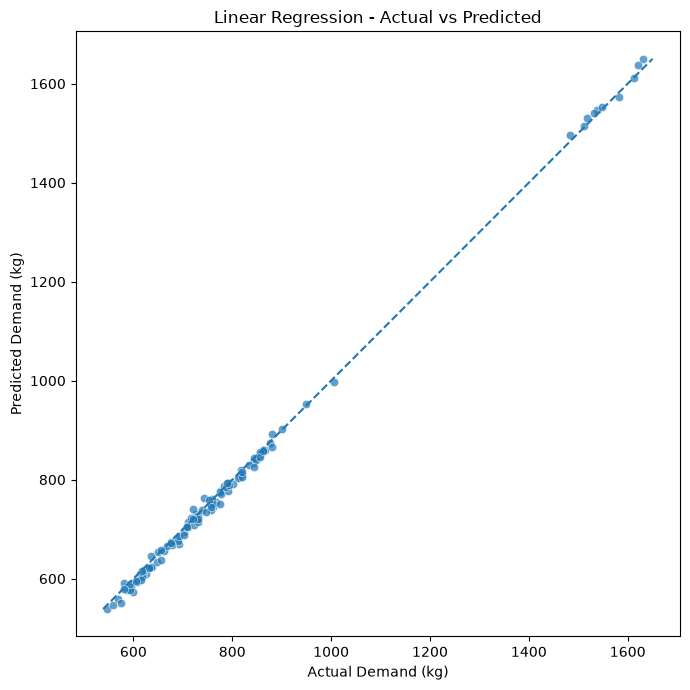

In [85]:
# Cell 33: Actual vs Predicted Scatter

plt.figure(figsize=(7, 7))

sns.scatterplot(
    x=y_test,
    y=test_predictions,
    alpha=0.7
)

minimum = min(
    y_test.min(),
    test_predictions.min()
)

maximum = max(
    y_test.max(),
    test_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title(
    "Linear Regression - Actual vs Predicted"
)

plt.xlabel(
    "Actual Demand (kg)"
)

plt.ylabel(
    "Predicted Demand (kg)"
)

plt.tight_layout()
plt.show()

In [86]:
# Cell 34: Error Analysis

error_analysis = test_df[
    [
        "date",
        "location",
        "crop",
        "demand_kg"
    ]
].copy()

error_analysis[
    "predicted_demand_kg"
] = test_predictions

error_analysis["error"] = (
    error_analysis["demand_kg"]
    - error_analysis["predicted_demand_kg"]
)

error_analysis["absolute_error"] = (
    error_analysis["error"].abs()
)

error_analysis["percentage_error"] = np.where(
    error_analysis["demand_kg"] != 0,
    (
        error_analysis["absolute_error"]
        / error_analysis["demand_kg"]
    ) * 100,
    np.nan
)

display(
    error_analysis
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(10)
)

,date,location,crop,demand_kg,predicted_demand_kg,error,absolute_error,percentage_error
716,2025-08-14,Panipat,Onion,599.0,573.973944,25.026056,25.026056,4.177973
748,2025-09-15,Meerut,Onion,776.0,751.460586,24.539414,24.539414,3.162296
755,2025-09-22,Panipat,Onion,575.0,551.595336,23.404664,23.404664,4.070376
665,2025-06-24,Meerut,Onion,693.0,670.703419,22.296581,22.296581,3.217400
710,2025-08-08,Sonipat,Onion,721.0,741.604995,-20.604995,20.604995,2.857836
695,2025-07-24,Gurugram,Onion,743.0,763.317176,-20.317176,20.317176,2.734479
684,2025-07-13,Delhi,Onion,1631.0,1650.188069,-19.188069,19.188069,1.176460
756,2025-09-23,Panipat,Onion,616.0,597.405528,18.594472,18.594472,3.018583
658,2025-06-17,Gurugram,Onion,757.0,739.003437,17.996563,17.996563,2.377353
734,2025-09-01,Ghaziabad,Onion,843.0,825.150235,17.849765,17.849765,2.117410


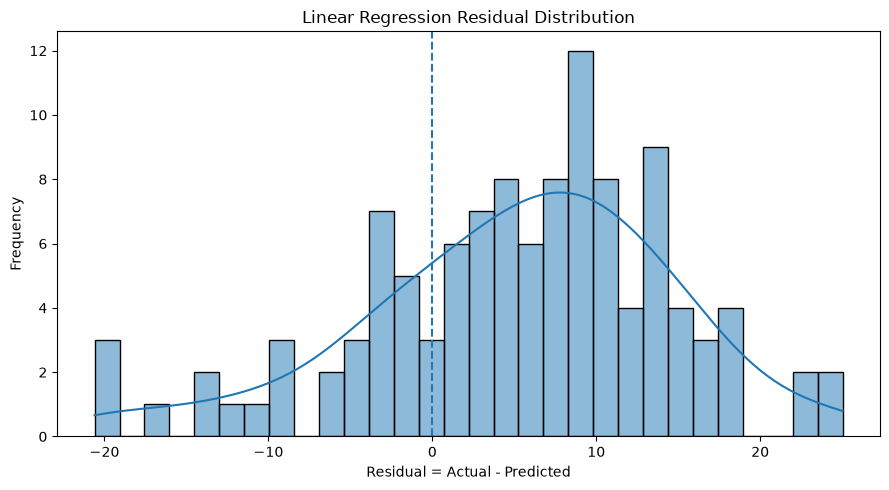

In [87]:
# Cell 35: Residual Distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    error_analysis["error"],
    bins=30,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Linear Regression Residual Distribution"
)

plt.xlabel(
    "Residual = Actual - Predicted"
)

plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [88]:
# Cell 36: Overfitting Check

train_rmse = train_metrics["RMSE"]
validation_rmse = validation_metrics["RMSE"]
test_rmse = test_metrics["RMSE"]

print(
    f"Train RMSE      : {train_rmse:.3f}"
)

print(
    f"Validation RMSE : {validation_rmse:.3f}"
)

print(
    f"Test RMSE       : {test_rmse:.3f}"
)

gap = (
    validation_rmse
    - train_rmse
)

print(
    f"\nTrain → Validation RMSE gap: {gap:.3f}"
)

if gap > 0.30 * train_rmse:
    print(
        "There may be noticeable overfitting."
    )
else:
    print(
        "No strong evidence of severe overfitting "
        "from this simple RMSE-gap check."
    )

Train RMSE      : 15.347
Validation RMSE : 19.273
Test RMSE       : 10.656

Train → Validation RMSE gap: 3.927
No strong evidence of severe overfitting from this simple RMSE-gap check.


In [89]:
# Cell 37: Final Model Selection

best_model_name = "Linear Regression"

print(
    "Best Model:",
    best_model_name
)

print(
    "Reason: XGBoost was showing overfitting, "
    "so Linear Regression is selected as the final model."
)

Best Model: Linear Regression
Reason: XGBoost was showing overfitting, so Linear Regression is selected as the final model.


In [90]:
# Cell 38: Final Training

X_train_validation = pd.concat(
    [X_train, X_val],
    axis=0
).sort_index()

y_train_validation = pd.concat(
    [y_train, y_val],
    axis=0
).sort_index()

# Create a completely fresh final pipeline
final_model = Pipeline([
    (
        "preprocessor",

        ColumnTransformer([
            (
                "numeric",

                SimpleImputer(
                    strategy="median"
                ),

                numeric_features
            ),

            (
                "categorical",

                Pipeline([
                    (
                        "imputer",

                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),

                    (
                        "encoder",

                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        )
                    )
                ]),

                categorical_features
            )
        ])
    ),

    (
        "model",
        LinearRegression()
    )
])

final_model.fit(
    X_train_validation,
    y_train_validation
)

print(
    "Final Linear Regression model trained successfully."
)

print(
    "Training + Validation rows:",
    len(X_train_validation)
)

Final Linear Regression model trained successfully.
Training + Validation rows: 646


In [91]:
# Cell 38: Final Training

X_train_validation = pd.concat(
    [X_train, X_val],
    axis=0
).sort_index()

y_train_validation = pd.concat(
    [y_train, y_val],
    axis=0
).sort_index()

# Create a completely fresh final pipeline
final_model = Pipeline([
    (
        "preprocessor",

        ColumnTransformer([
            (
                "numeric",

                SimpleImputer(
                    strategy="median"
                ),

                numeric_features
            ),

            (
                "categorical",

                Pipeline([
                    (
                        "imputer",

                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),

                    (
                        "encoder",

                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        )
                    )
                ]),

                categorical_features
            )
        ])
    ),

    (
        "model",
        LinearRegression()
    )
])

final_model.fit(
    X_train_validation,
    y_train_validation
)

print(
    "Final Linear Regression model trained successfully."
)

print(
    "Training + Validation rows:",
    len(X_train_validation)
)

Final Linear Regression model trained successfully.
Training + Validation rows: 646


In [93]:
# Cell 39: Final Test Evaluation

final_test_predictions = (
    final_model
    .predict(X_test)
)

final_test_metrics = calculate_metrics(
    y_test,
    final_test_predictions
)

print("FINAL LINEAR REGRESSION RESULTS")
print("=" * 50)

for metric, value in final_test_metrics.items():

    print(
        f"{metric}: {value:.3f}"
    )

FINAL LINEAR REGRESSION RESULTS
MAE: 7.282
RMSE: 9.510
R2: 0.999
MAPE (%): 0.917


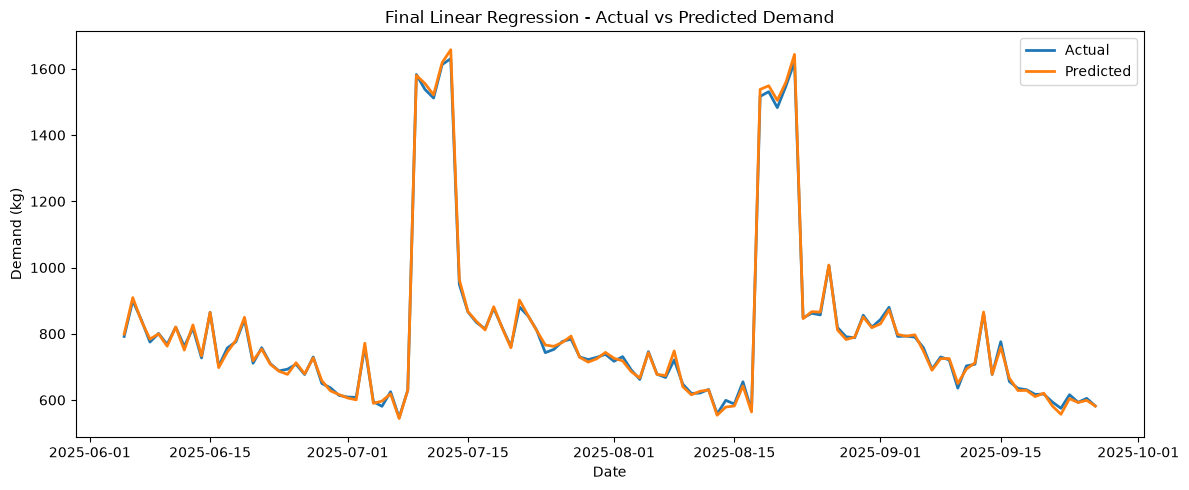

In [94]:
# Cell 40: Final Actual vs Predicted

plt.figure(figsize=(12, 5))

plt.plot(
    test_df["date"],
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    test_df["date"],
    final_test_predictions,
    label="Predicted",
    linewidth=2
)

plt.title(
    "Final Linear Regression - Actual vs Predicted Demand"
)

plt.xlabel("Date")
plt.ylabel("Demand (kg)")

plt.legend()

plt.tight_layout()
plt.show()

In [95]:
# Cell 41: Linear Regression Coefficients

fitted_preprocessor = (
    final_model
    .named_steps["preprocessor"]
)

fitted_lr = (
    final_model
    .named_steps["model"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

coefficient_df = pd.DataFrame({

    "Feature":
        feature_names,

    "Coefficient":
        fitted_lr.coef_

})

coefficient_df[
    "Absolute_Coefficient"
] = (
    coefficient_df["Coefficient"]
    .abs()
)

coefficient_df = (
    coefficient_df
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
)

display(
    coefficient_df.head(20)
)

,Feature,Coefficient,Absolute_Coefficient
4,numeric__festival_flag,122.129248,122.129248
28,categorical__location_Delhi,49.049281,49.049281
34,categorical__location_Panipat,-15.448191,15.448191
35,categorical__location_Sonipat,-12.082910,12.082910
29,categorical__location_Faridabad,-8.207779,8.207779
32,categorical__location_Meerut,-7.944167,7.944167
31,categorical__location_Gurugram,-7.359102,7.359102
14,numeric__month_cos,5.571144,5.571144
13,numeric__month_sin,4.280981,4.280981
33,categorical__location_Noida,3.652126,3.652126


In [96]:
# Cell 42: Save Final Model

MODEL_PATH = (
    "linear_regression_demand_model.joblib"
)

joblib.dump(
    final_model,
    MODEL_PATH
)

print(
    "Model saved successfully:"
)

print(
    MODEL_PATH
)

Model saved successfully:
linear_regression_demand_model.joblib


In [97]:
# Cell 43: Load Saved Model

loaded_model = joblib.load(
    MODEL_PATH
)

print(
    "Linear Regression model loaded successfully."
)

Linear Regression model loaded successfully.


In [98]:
# Cell 44: Build Future Features

def build_future_features(
    location,
    crop,
    future_date,
    price_per_kg,
    temperature_c,
    rainfall_mm,
    market_arrivals_kg,
    festival_flag,
    historical_df
):

    future_date = pd.Timestamp(
        future_date
    )

    # Get historical data before future date
    history = historical_df[
        (historical_df["location"] == location) &
        (historical_df["crop"] == crop) &
        (historical_df["date"] < future_date)
    ].sort_values("date")

    if len(history) < 30:

        raise ValueError(
            f"Only {len(history)} historical observations "
            f"found for {location}/{crop}. "
            f"At least 30 are required."
        )

    demand_history = (
        history["demand_kg"]
        .values
    )

    row = {}

    # Categorical
    row["location"] = location
    row["crop"] = crop

    # Future external variables
    row["price_per_kg"] = price_per_kg
    row["temperature_c"] = temperature_c
    row["rainfall_mm"] = rainfall_mm
    row["market_arrivals_kg"] = market_arrivals_kg
    row["festival_flag"] = festival_flag

    # Calendar features
    row["year"] = future_date.year
    row["month"] = future_date.month
    row["day"] = future_date.day
    row["day_of_week"] = future_date.dayofweek
    row["day_of_year"] = future_date.dayofyear

    row["week_of_year"] = int(
        future_date.isocalendar().week
    )

    row["quarter"] = future_date.quarter

    row["is_weekend"] = int(
        future_date.dayofweek >= 5
    )

    # Cyclical features
    row["month_sin"] = np.sin(
        2 * np.pi *
        row["month"] / 12
    )

    row["month_cos"] = np.cos(
        2 * np.pi *
        row["month"] / 12
    )

    row["day_of_week_sin"] = np.sin(
        2 * np.pi *
        row["day_of_week"] / 7
    )

    row["day_of_week_cos"] = np.cos(
        2 * np.pi *
        row["day_of_week"] / 7
    )

    # Lag features
    for lag in [
        1,
        2,
        3,
        7,
        14,
        30
    ]:

        row[f"lag_{lag}"] = (
            demand_history[-lag]
        )

    # Rolling features
    row["rolling_mean_7"] = (
        demand_history[-7:].mean()
    )

    row["rolling_mean_14"] = (
        demand_history[-14:].mean()
    )

    row["rolling_mean_30"] = (
        demand_history[-30:].mean()
    )

    row["rolling_std_7"] = (
        demand_history[-7:].std()
    )

    row["rolling_std_30"] = (
        demand_history[-30:].std()
    )

    future_df = pd.DataFrame(
        [row]
    )

    return future_df[
        feature_columns
    ]

In [99]:
# Cell 45: Predict Next Day Demand

latest_date = df["date"].max()

future_date = (
    latest_date
    + pd.Timedelta(days=1)
)

location = "Noida"
crop = "Onion"

history = df[
    (df["location"] == location) &
    (df["crop"] == crop)
].sort_values("date")

latest_row = history.iloc[-1]

future_features = build_future_features(

    location=location,

    crop=crop,

    future_date=future_date,

    price_per_kg=
        latest_row["price_per_kg"],

    temperature_c=
        latest_row["temperature_c"],

    rainfall_mm=
        latest_row["rainfall_mm"],

    market_arrivals_kg=
        latest_row["market_arrivals_kg"],

    festival_flag=
        latest_row["festival_flag"],

    historical_df=df
)

future_prediction = (
    loaded_model
    .predict(future_features)[0]
)

# Demand cannot be negative
future_prediction = max(
    0,
    future_prediction
)

print("Future Date:", future_date.date())
print("Location:", location)
print("Crop:", crop)

print(
    f"\nPredicted Demand: "
    f"{future_prediction:.2f} kg"
)

Future Date: 2025-09-27
Location: Noida
Crop: Onion

Predicted Demand: 806.67 kg


In [101]:
# Cell 46: Reusable Demand Prediction Function

def predict_demand(
    location,
    crop,
    future_date,
    price_per_kg,
    temperature_c,
    rainfall_mm,
    market_arrivals_kg,
    festival_flag
):

    features = build_future_features(

        location=location,

        crop=crop,

        future_date=future_date,

        price_per_kg=price_per_kg,

        temperature_c=temperature_c,

        rainfall_mm=rainfall_mm,

        market_arrivals_kg=
            market_arrivals_kg,

        festival_flag=
            festival_flag,

        historical_df=df
    )

    prediction = (
        loaded_model
        .predict(features)[0]
    )

    return max(
        0,
        float(prediction)
    )

In [102]:
# Cell 47: Forecast All Locations

forecast_date = (
    df["date"].max()
    + pd.Timedelta(days=1)
)

crop = "Onion"

locations = sorted(
    df["location"].unique()
)

forecast_results = []

for location in locations:

    history = df[
        (df["location"] == location) &
        (df["crop"] == crop)
    ].sort_values("date")

    latest = history.iloc[-1]

    prediction = predict_demand(

        location=location,

        crop=crop,

        future_date=forecast_date,

        price_per_kg=
            latest["price_per_kg"],

        temperature_c=
            latest["temperature_c"],

        rainfall_mm=
            latest["rainfall_mm"],

        market_arrivals_kg=
            latest["market_arrivals_kg"],

        festival_flag=
            latest["festival_flag"]
    )

    forecast_results.append({

        "date":
            forecast_date,

        "location":
            location,

        "crop":
            crop,

        "predicted_demand_kg":
            prediction
    })


forecast_df = pd.DataFrame(
    forecast_results
)

forecast_df = (
    forecast_df
    .sort_values(
        "predicted_demand_kg",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    forecast_df.round(2)
)

,date,location,crop,predicted_demand_kg
0,2025-09-27,Delhi,Onion,1640.07
1,2025-09-27,Ghaziabad,Onion,832.51
2,2025-09-27,Noida,Onion,806.67
3,2025-09-27,Gurugram,Onion,750.78
4,2025-09-27,Faridabad,Onion,695.16
5,2025-09-27,Meerut,Onion,658.19
6,2025-09-27,Sonipat,Onion,581.62
7,2025-09-27,Panipat,Onion,579.16


In [105]:
# Cell 48: Create Routing Input

routing_df = forecast_df[
    forecast_df[
        "predicted_demand_kg"
    ] > 0
].copy()

routing_df = routing_df[
    [
        "location",
        "crop",
        "predicted_demand_kg"
    ]
]

routing_df.to_csv(
    "predicted_demand_for_routing.csv",
    index=False
)

print(
    "Routing file created successfully."
)

display(
    routing_df.round(2)
)

Routing file created successfully.


,location,crop,predicted_demand_kg
0,Delhi,Onion,1640.07
1,Ghaziabad,Onion,832.51
2,Noida,Onion,806.67
3,Gurugram,Onion,750.78
4,Faridabad,Onion,695.16
5,Meerut,Onion,658.19
6,Sonipat,Onion,581.62
7,Panipat,Onion,579.16
